#### Introduction

Nitrogen is a major limiting resource for plants and a large component of fertilizer. If plants do not have access to sufficient nitrogen, they may quickly become stressed and experience yield loss. Measuring nitrogen content, however, can be invasive, time-consuming, and expensive. Soil samples can be difficult to collect, may take weeks to get results from, and are costly. Soil collars are easier to collect data from, but may not be representative of a whole field. My research deals is focused on using tomato plants as biosensors to get feedback on soil nitrogen content in real time. CEPD-RUBY tomato plants, which are bioengineered in the CEPD pathway release red pigment in the roots, shoots, and leaves, when experiencing nitrogen stress. Because of this, they can be placed throughout a field and their coloration can be used as a biological indicator of nitrogen stress. Ideally, based on the intensity of red coloration, specific amounts of fertilizer can be added to bring the soil up to productive nitrogen levels, without needing to do invasive testing. Controlled hydroponic experiments have been done which show the presence of red nitrogen stress coloration in CEPD-RUBY plants, known as RUBY plants from here on out, however, these plants were not tested in a field setting until 2025. 
In the summer of 2025, RUBY plants were planted in a randomized complete block design. One line of RUBY plants was used, along with wildtype plants of the same genotype as the RUBY plants: M82. Half of these plants experienced a standard nitrogen treatment, where they would not be exposed to much nitrogen stress, while the other half of the field experienced a low nitrogen treatment and thus lacked sufficient nitrogen. One of the main goals of the field experiment was to characterize the coloration level of the RUBY plants across time, both to compare between the low and standard nitrogen treatments, and to compare between the RUBY plants and the wildtype control plants. To answer these questions, I am analyzing a dataset which consists of a series of multispectral drone flights over the field across the 3 months wherein the tomato plants were grown.  

#### Materials and Methods

When the drone was flown over the tomato field at a height of 30 meters, it took individual images, with significant overlap of the image on each pass of the drone. With the multispectral camera, images are collected in 5 bands: red, green, blue, red edge, and near-infrared. Values from these bands can be used in various color indices to compare plant coloration in the resulting images. A grey reference square is imaged before every flight, and images are automatically calibrated against the reference value, so that changes in coloration between flight dates can be attributed to changes in the field itself rather than simply a difference in cloud cover or the angle and intensity of the sun. Once the images are taken, they need be stitched together into a single image of the field, an orthomosaic. This is done using reference points from the field, black and white squares which are staked to the ground, so they are in the same location every flight, and are easily visible by the drone. Once the overlapped images are stitched together and tethered to the reference points, areas of the orthomosaic can be compared across dates.

To identify the coloration of individual plants, a grid must be made to distinguish the location of each plant. Due to the reference point calibration, a single grid can be used across all dates. The grid was made at the plot level, then the plant level. From here, plant masks can be made so that coloration of a plant can be measured without including the surrounding area. As an attempt to make quick automated plant masks, circular masks were applied to each plant. However, these masks do not adequately encompass plant material or exclude soil material, as I will show later. To make the circluar masks, an ndvi mask is applied to the field orthomosaic. The pixel values are thresholded so that values above 0.2 on the ndvi scale become white while values below 0.2 become black, creating a binary mask. From here, connected component analysis is done on contiguous white pixels. Each pixel group constitutes a potential plant. The center of these groups is found, and each group is converted to a circle. The resulting mask of circles is cleaned manually, so that the only circles remaining are at plant locations. The size of the circles can be changed, so that smaller circles are used when the plants are younger and larger masks are used as they mature. 

There are several indices which function well to examine red vs green coloration in the plants. First, there is BGI, the blue-green index, defined as reflectance in the 450 nanometer range divided by reflectance in the 550 nanometer range, or $\text{BGI} = \frac{\text{Green}}{\text{Blue}}$. Higher values indicate higher greenness while lower values indicate lower greenness.

Next, there is RGI, the red-green index. Red is defined as wavelengths 640-760nm, while green is wavelengths 490-570nm. The index is calculated as $\text{RGI} = \frac{\text{Red} - \text{Green}}{\text{Red} + \text{Green}}$. Greener plants have lower values, while redder plants have higher values. 

Finally, there is $a^*$, which is part of the $L^*a^*b^*$ color space, and is defined as a unitless scale from green to red, ranging from -128 - 127. $a^* = 500 \left( f\left(\frac{X}{X_n}\right) - f\left(\frac{Y}{Y_n}\right) \right)$ where $X_n$ and $Y_n$ are white reference values, and X and Y are the observed values. For simplicity, and to be parsimonious with previous RUBY experiments, which also use the $a^*$ index, this analysis will only use $a^*$ index values for modeling.

The circular masks, while fairly simple to create, do not capture plant data adequately for early drone flight dates. There are 11 flight dates. Looking at the spread of the raw data in BGI, RGI, and a*, when the mask is applied, there is differentiation between plant coloration in later dates but the values of earlier dates do not change much from their unmasked values. It is expected that wildtype plants will have less red coloration than RUBY plants, that wildtype plants in the low nitrogen treatment will be less green than wildtype plants in the standard trial due to increased stress, and that RUBY plants in the low nitrogen treatment will be more red than their counterparts in the standard nitrogen treatment. This differentiation may take time to appear, however the cross-group drop from high red coloration to lower coloration in the later dates, suggests that red soil coloration is present in the early date masks rather than solely plant material. You can see the increased differentiation in later dates with the addition of masking below in the BGI, RGI, and $a^*$ index. The 4 lines in each graph show the RUBY plants in the low nitrogen treatment, the RUBY plants in the standard nitrogen treatment, the wildtype plants in the low nitrogen treatment, and the wildtype plants in the standard nitrogen treatment.

In [62]:
from pdf2image import convert_from_path
from IPython.display import display

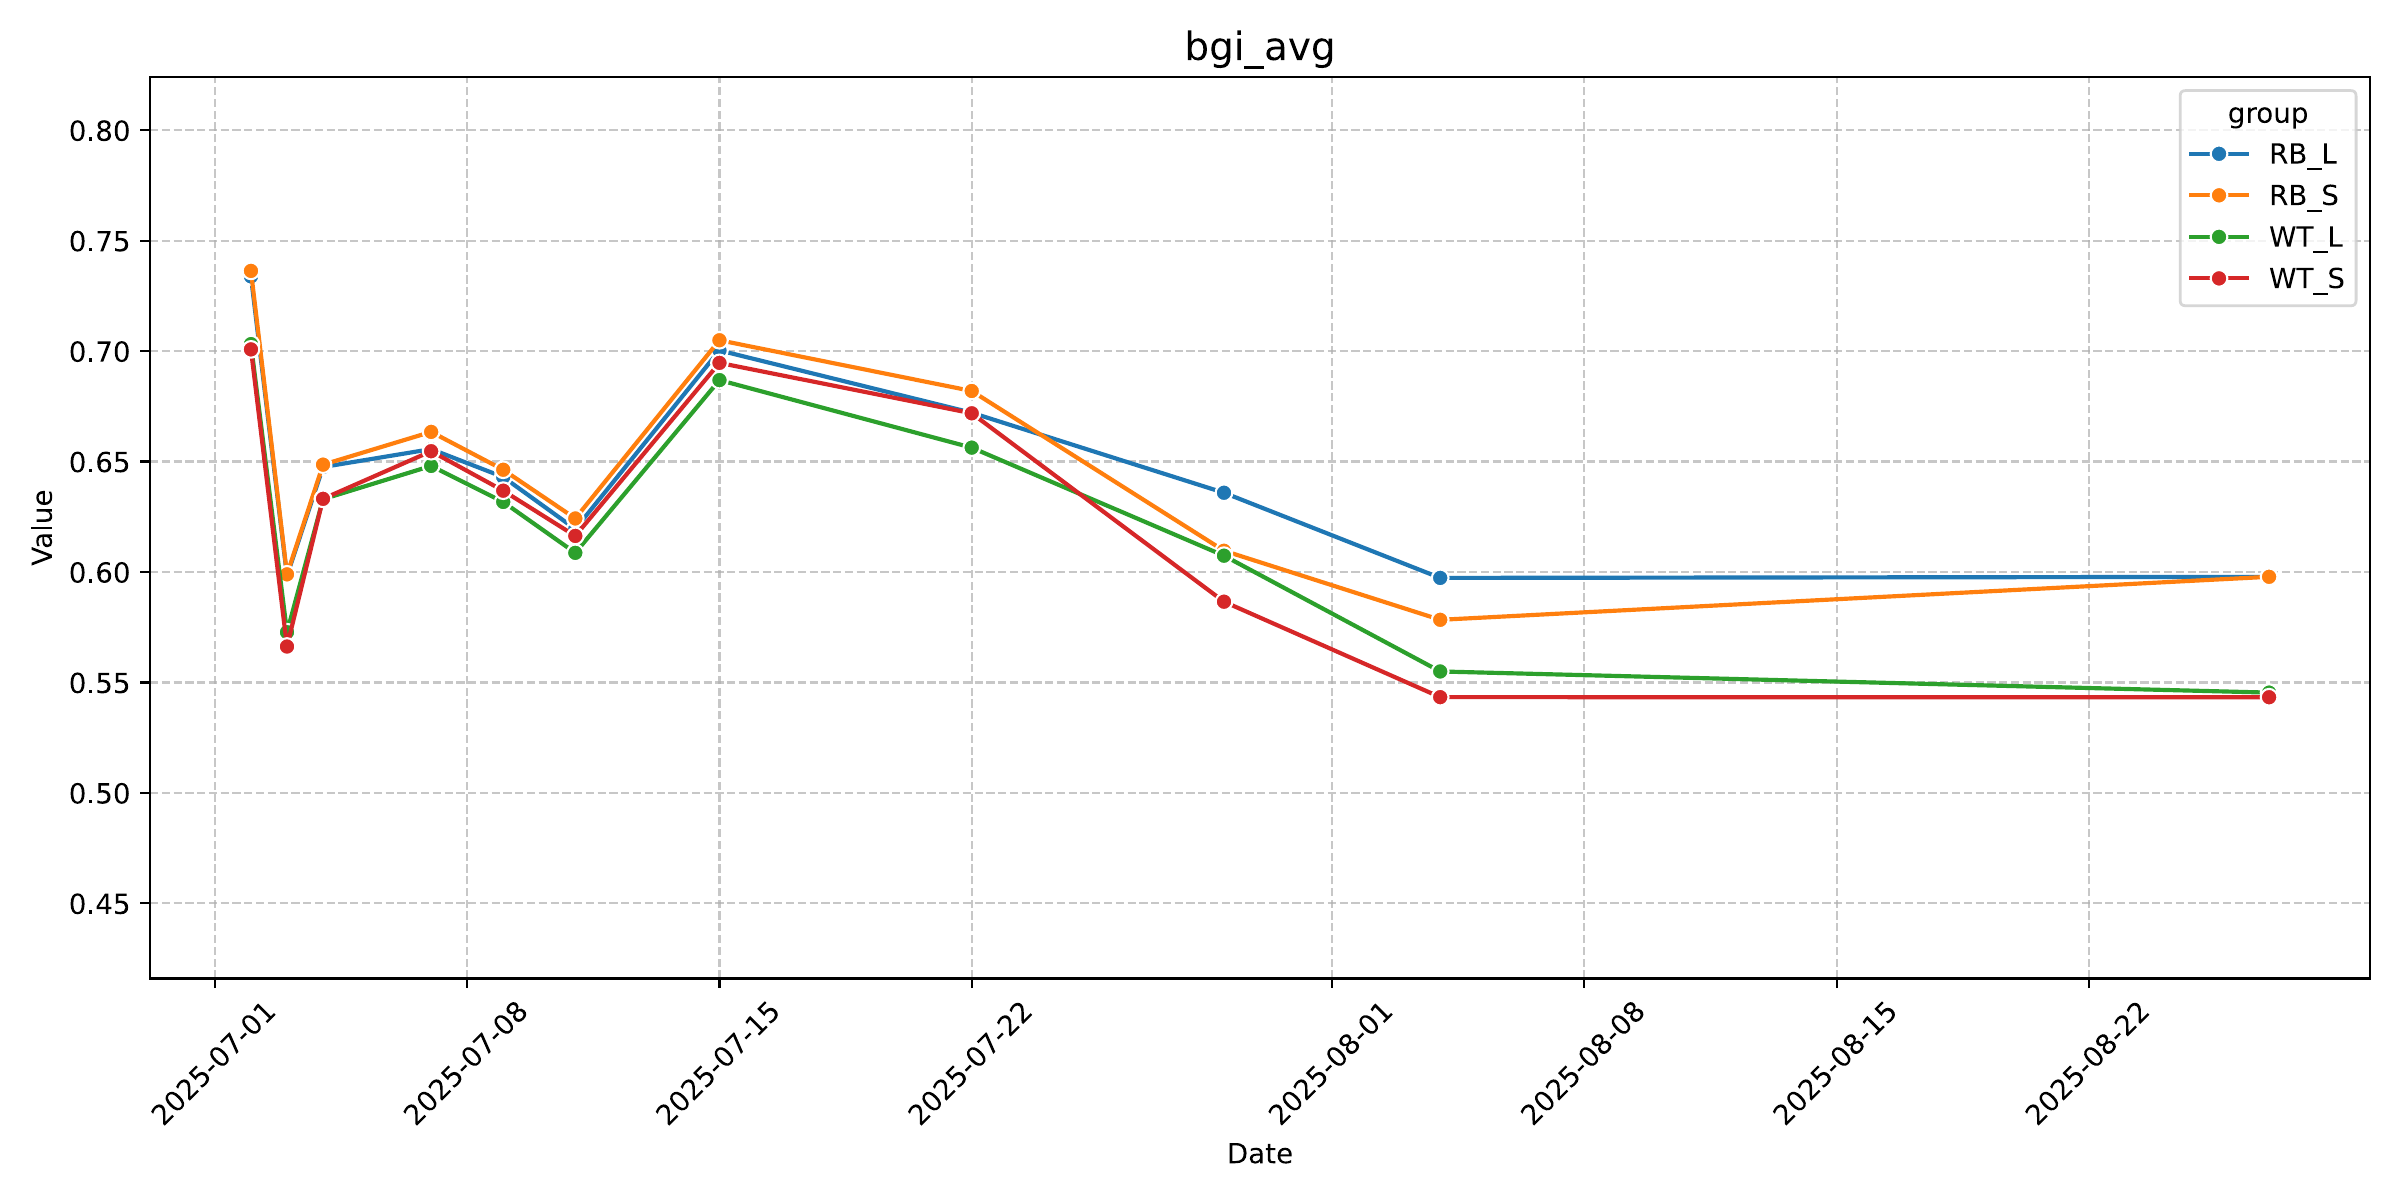

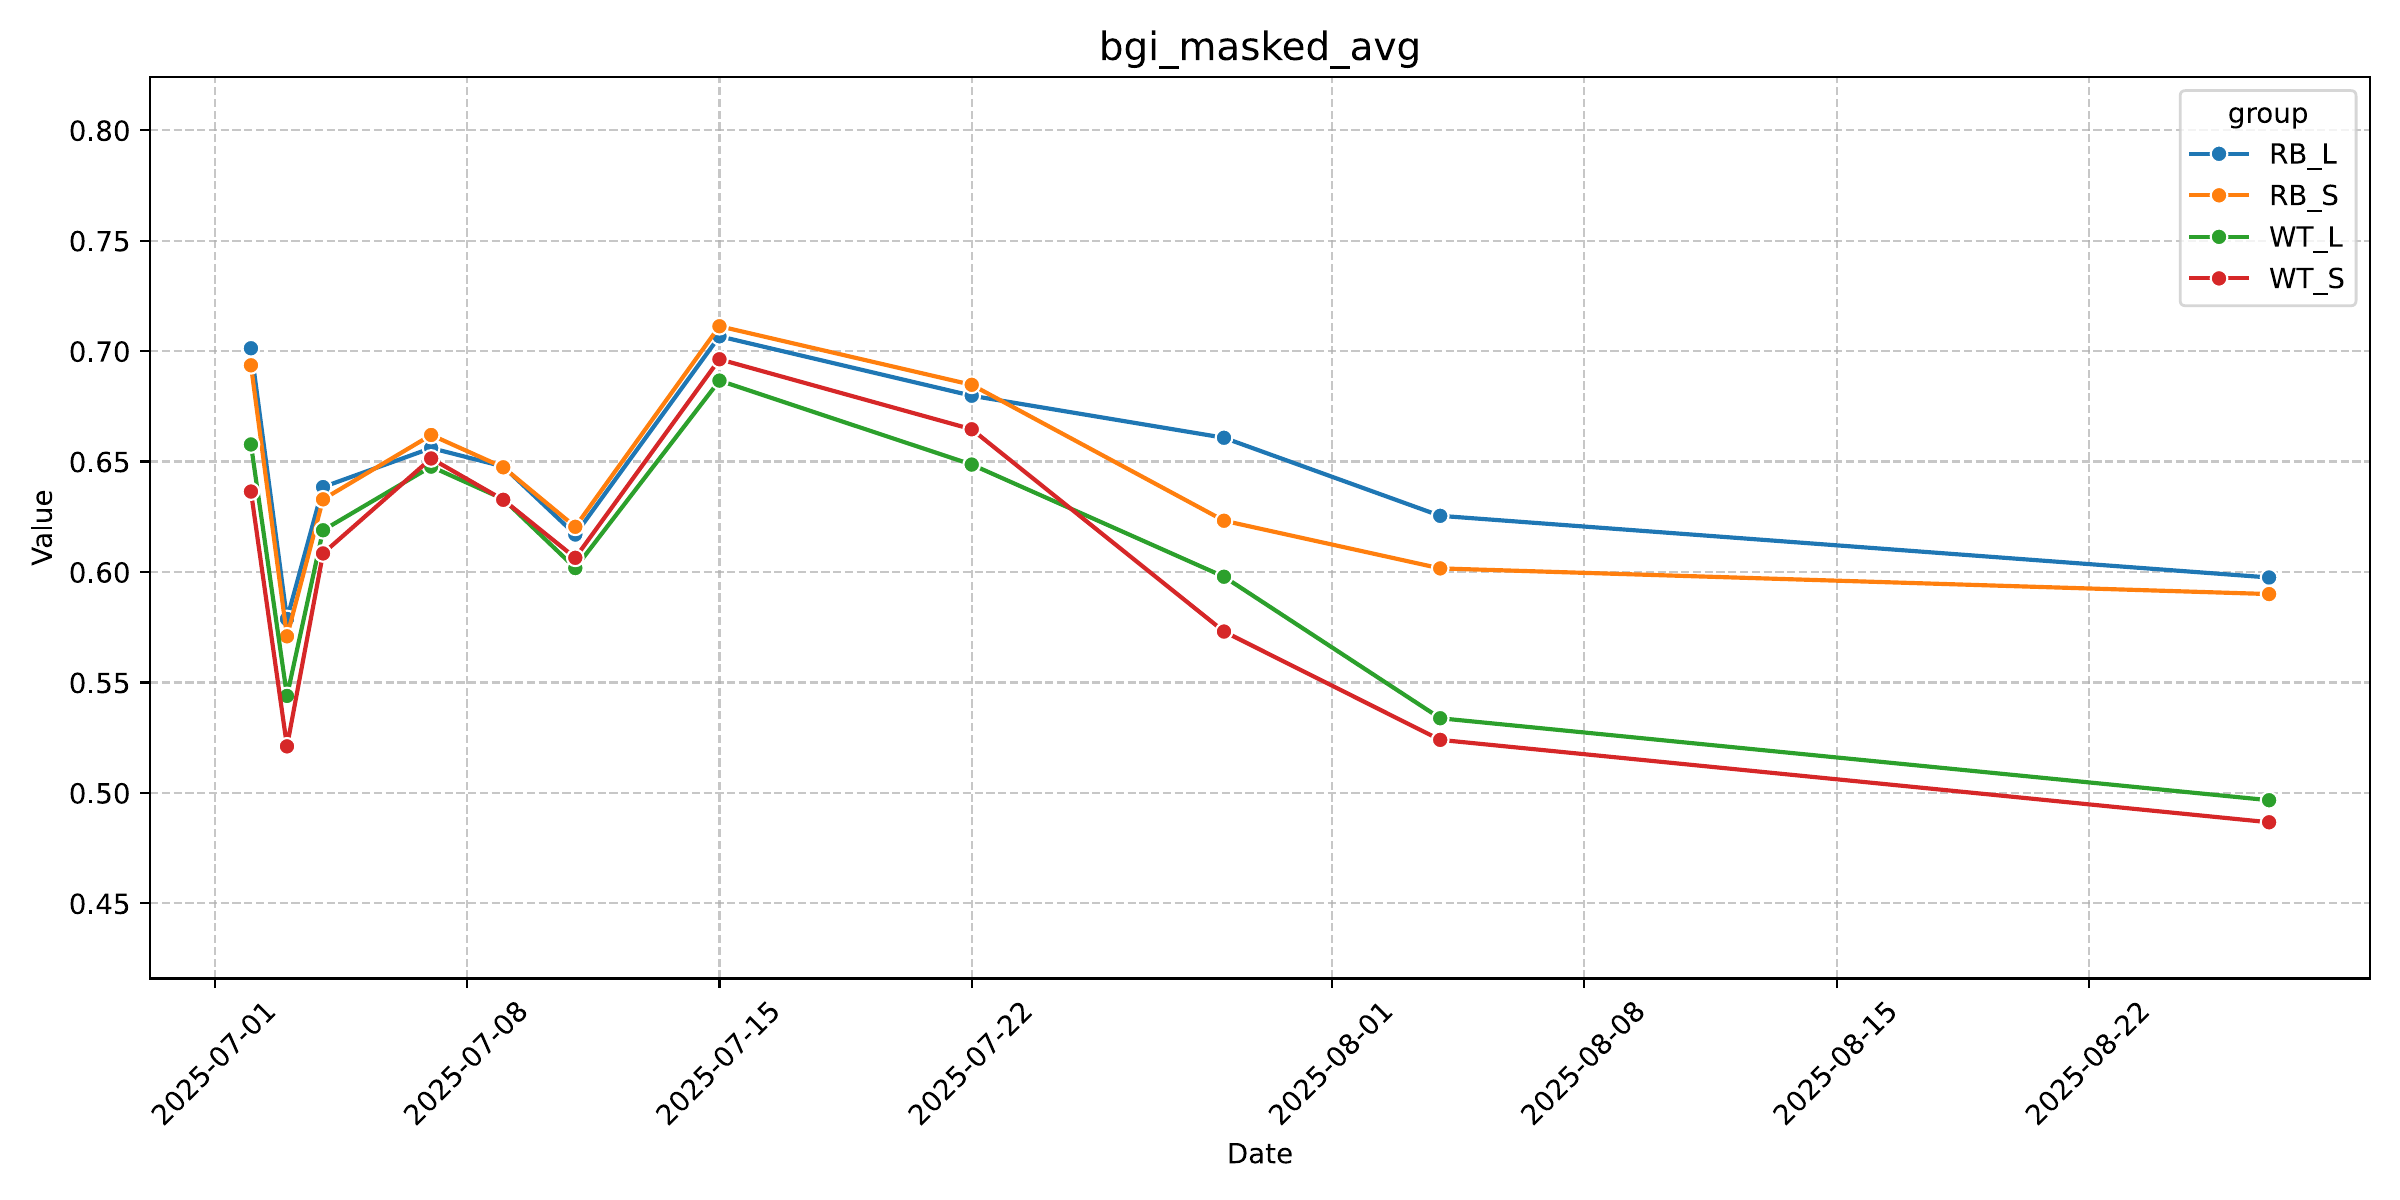

In [ ]:
pdf_path = "Multidate_Analysis/raw_bgi_across_dates.pdf"

# Convert the first page of the PDF to an image object (dpi=200 makes it crisp)
pages = convert_from_path(pdf_path, dpi=200)

# Display the image in the notebook
if pages:
    display(pages[0])
    display(pages[1])

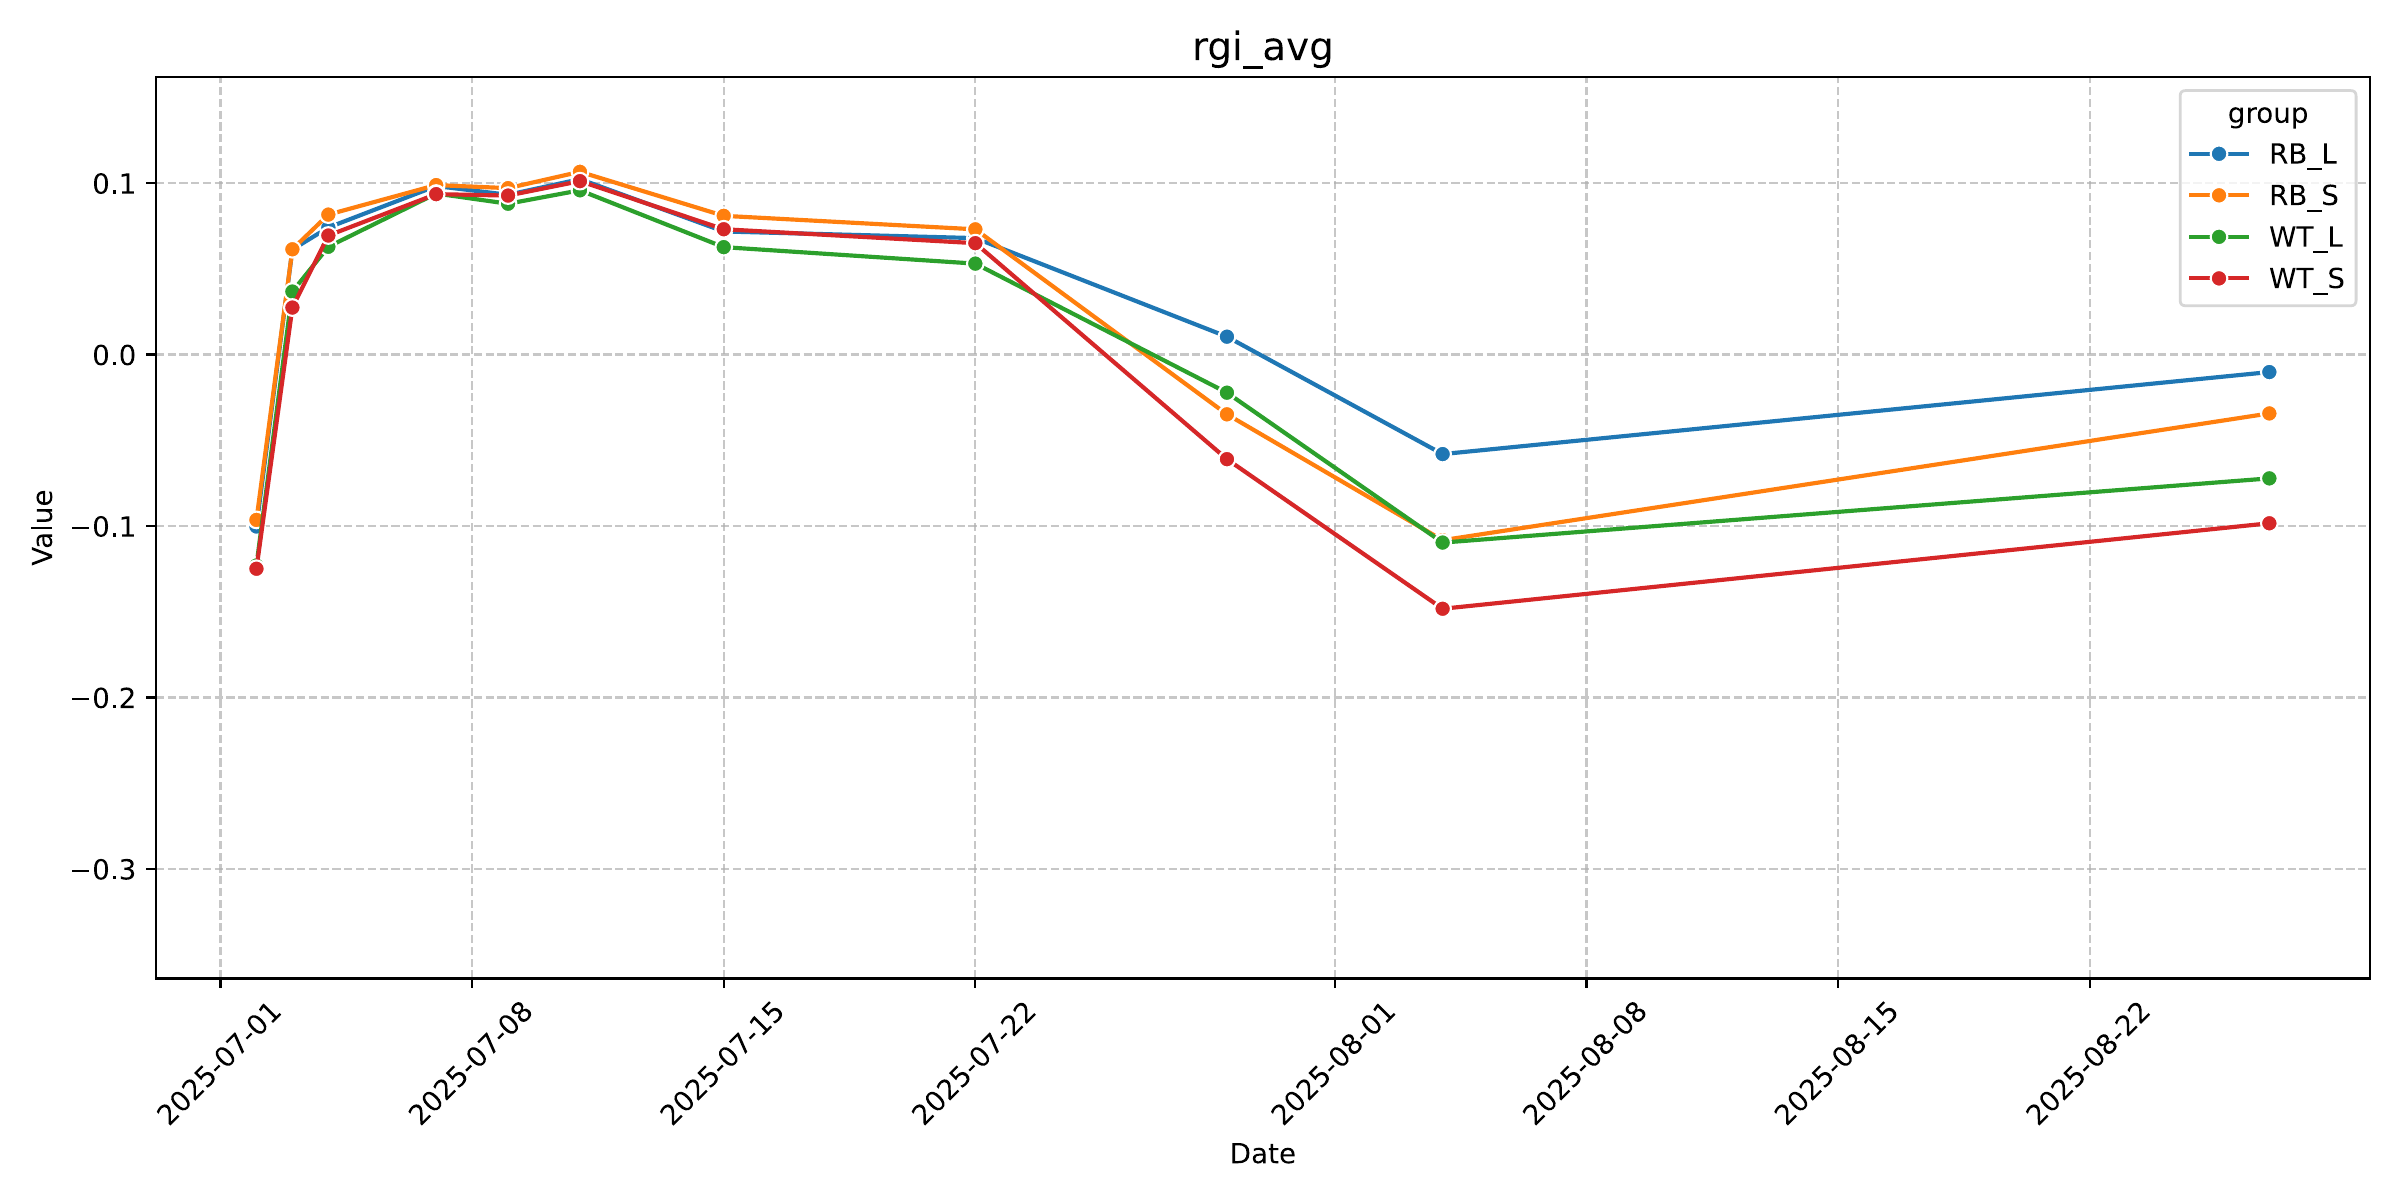

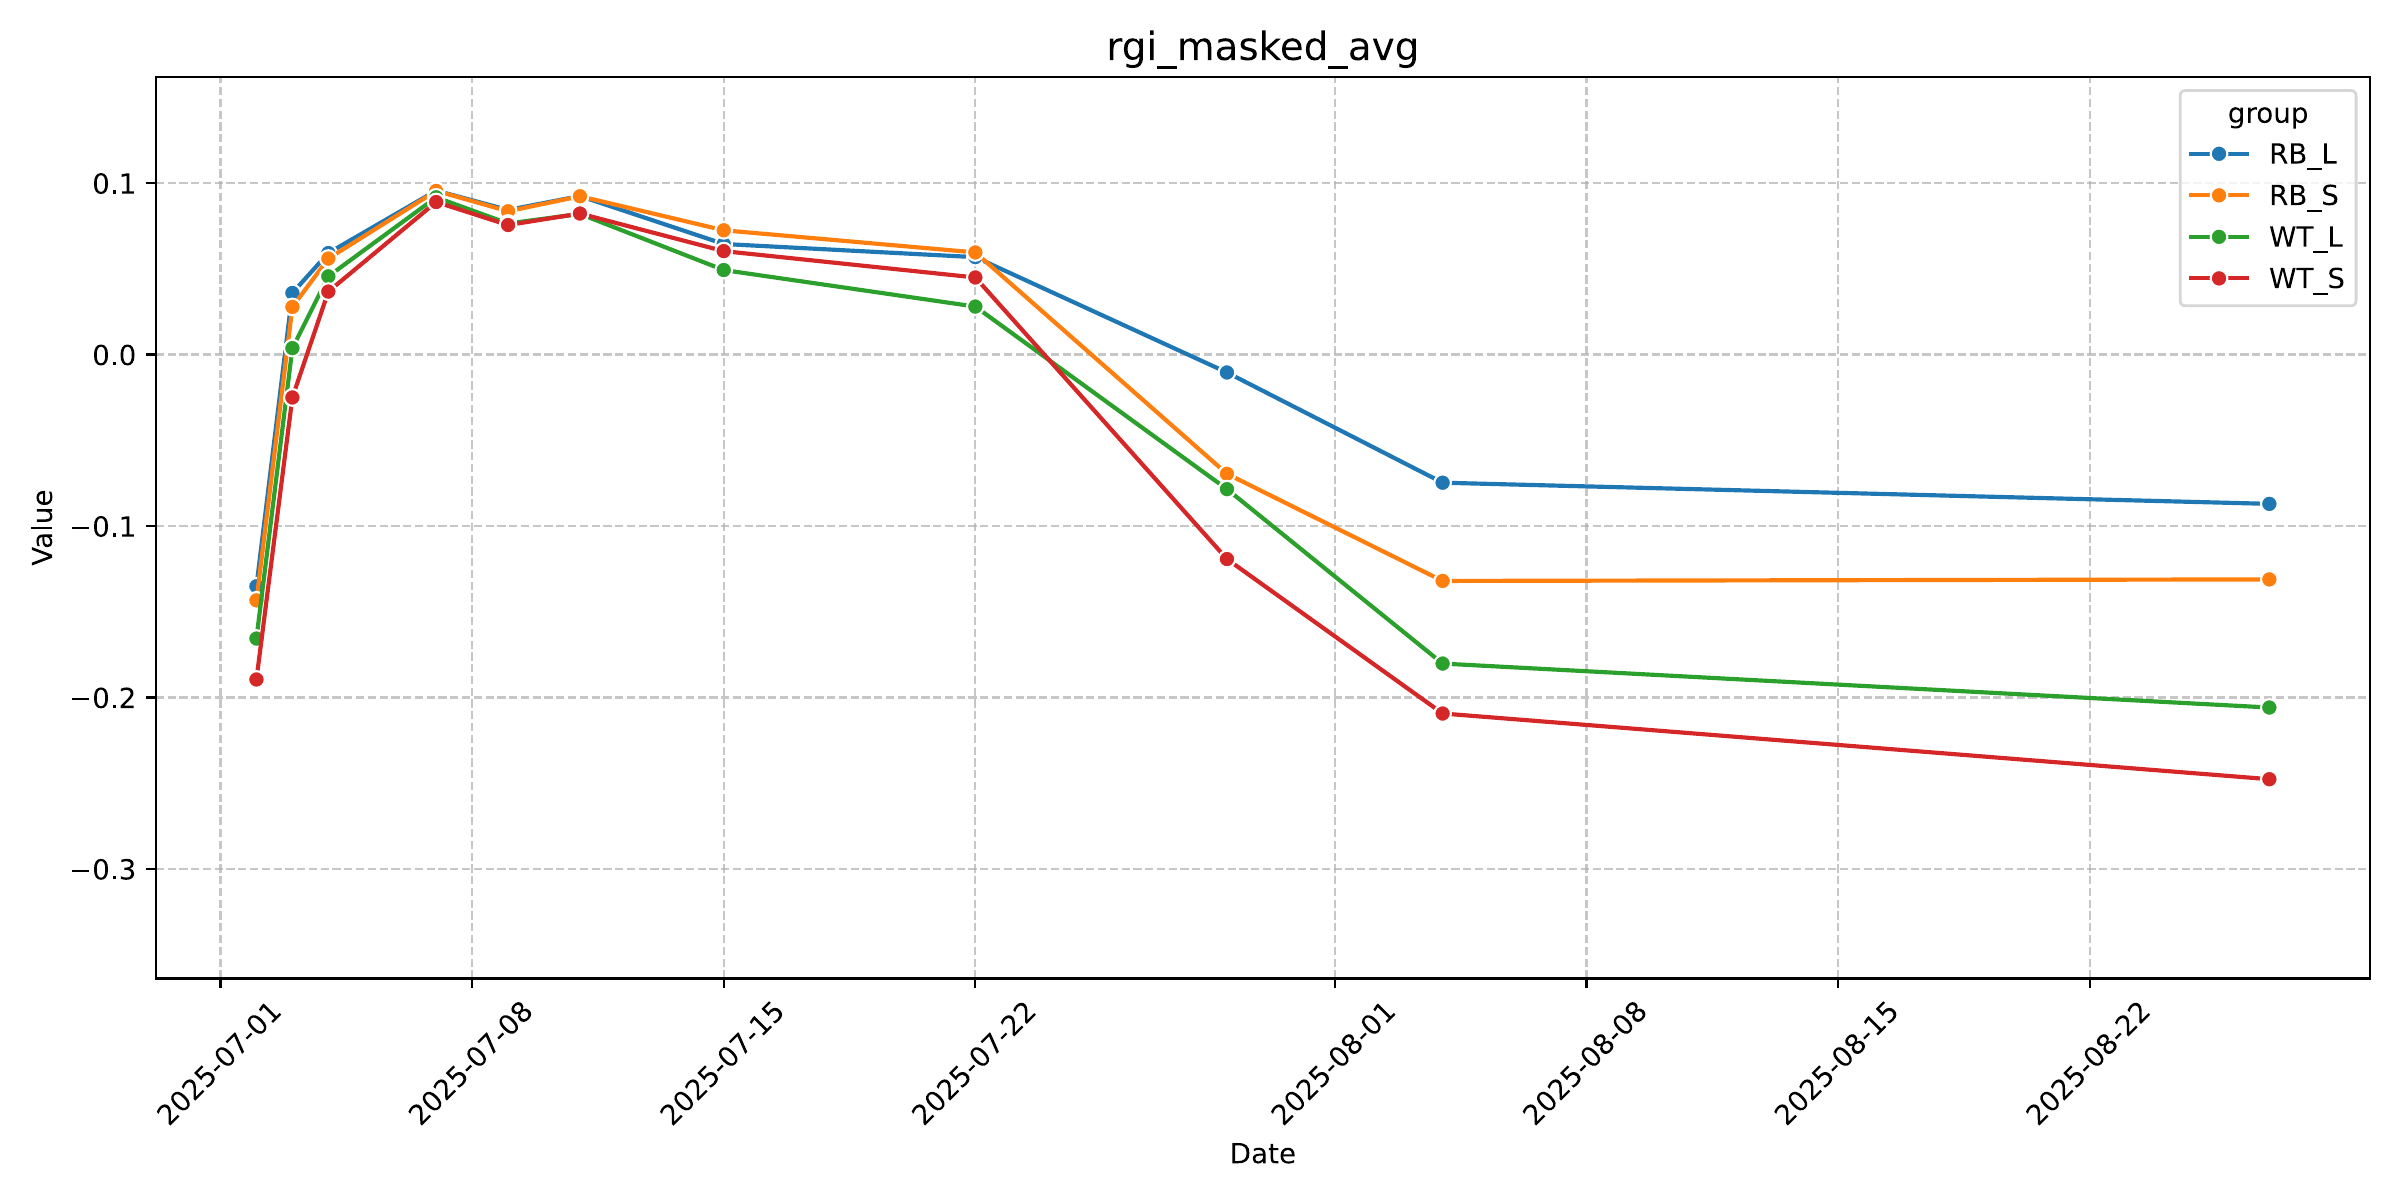

In [ ]:
pdf_path = "Multidate_Analysis/raw_rgi_across_dates.pdf"

# Convert the first page of the PDF to an image object (dpi=200 makes it crisp)
pages = convert_from_path(pdf_path, dpi=200)

# Display the image in the notebook
if pages:
    display(pages[0])
    display(pages[1])

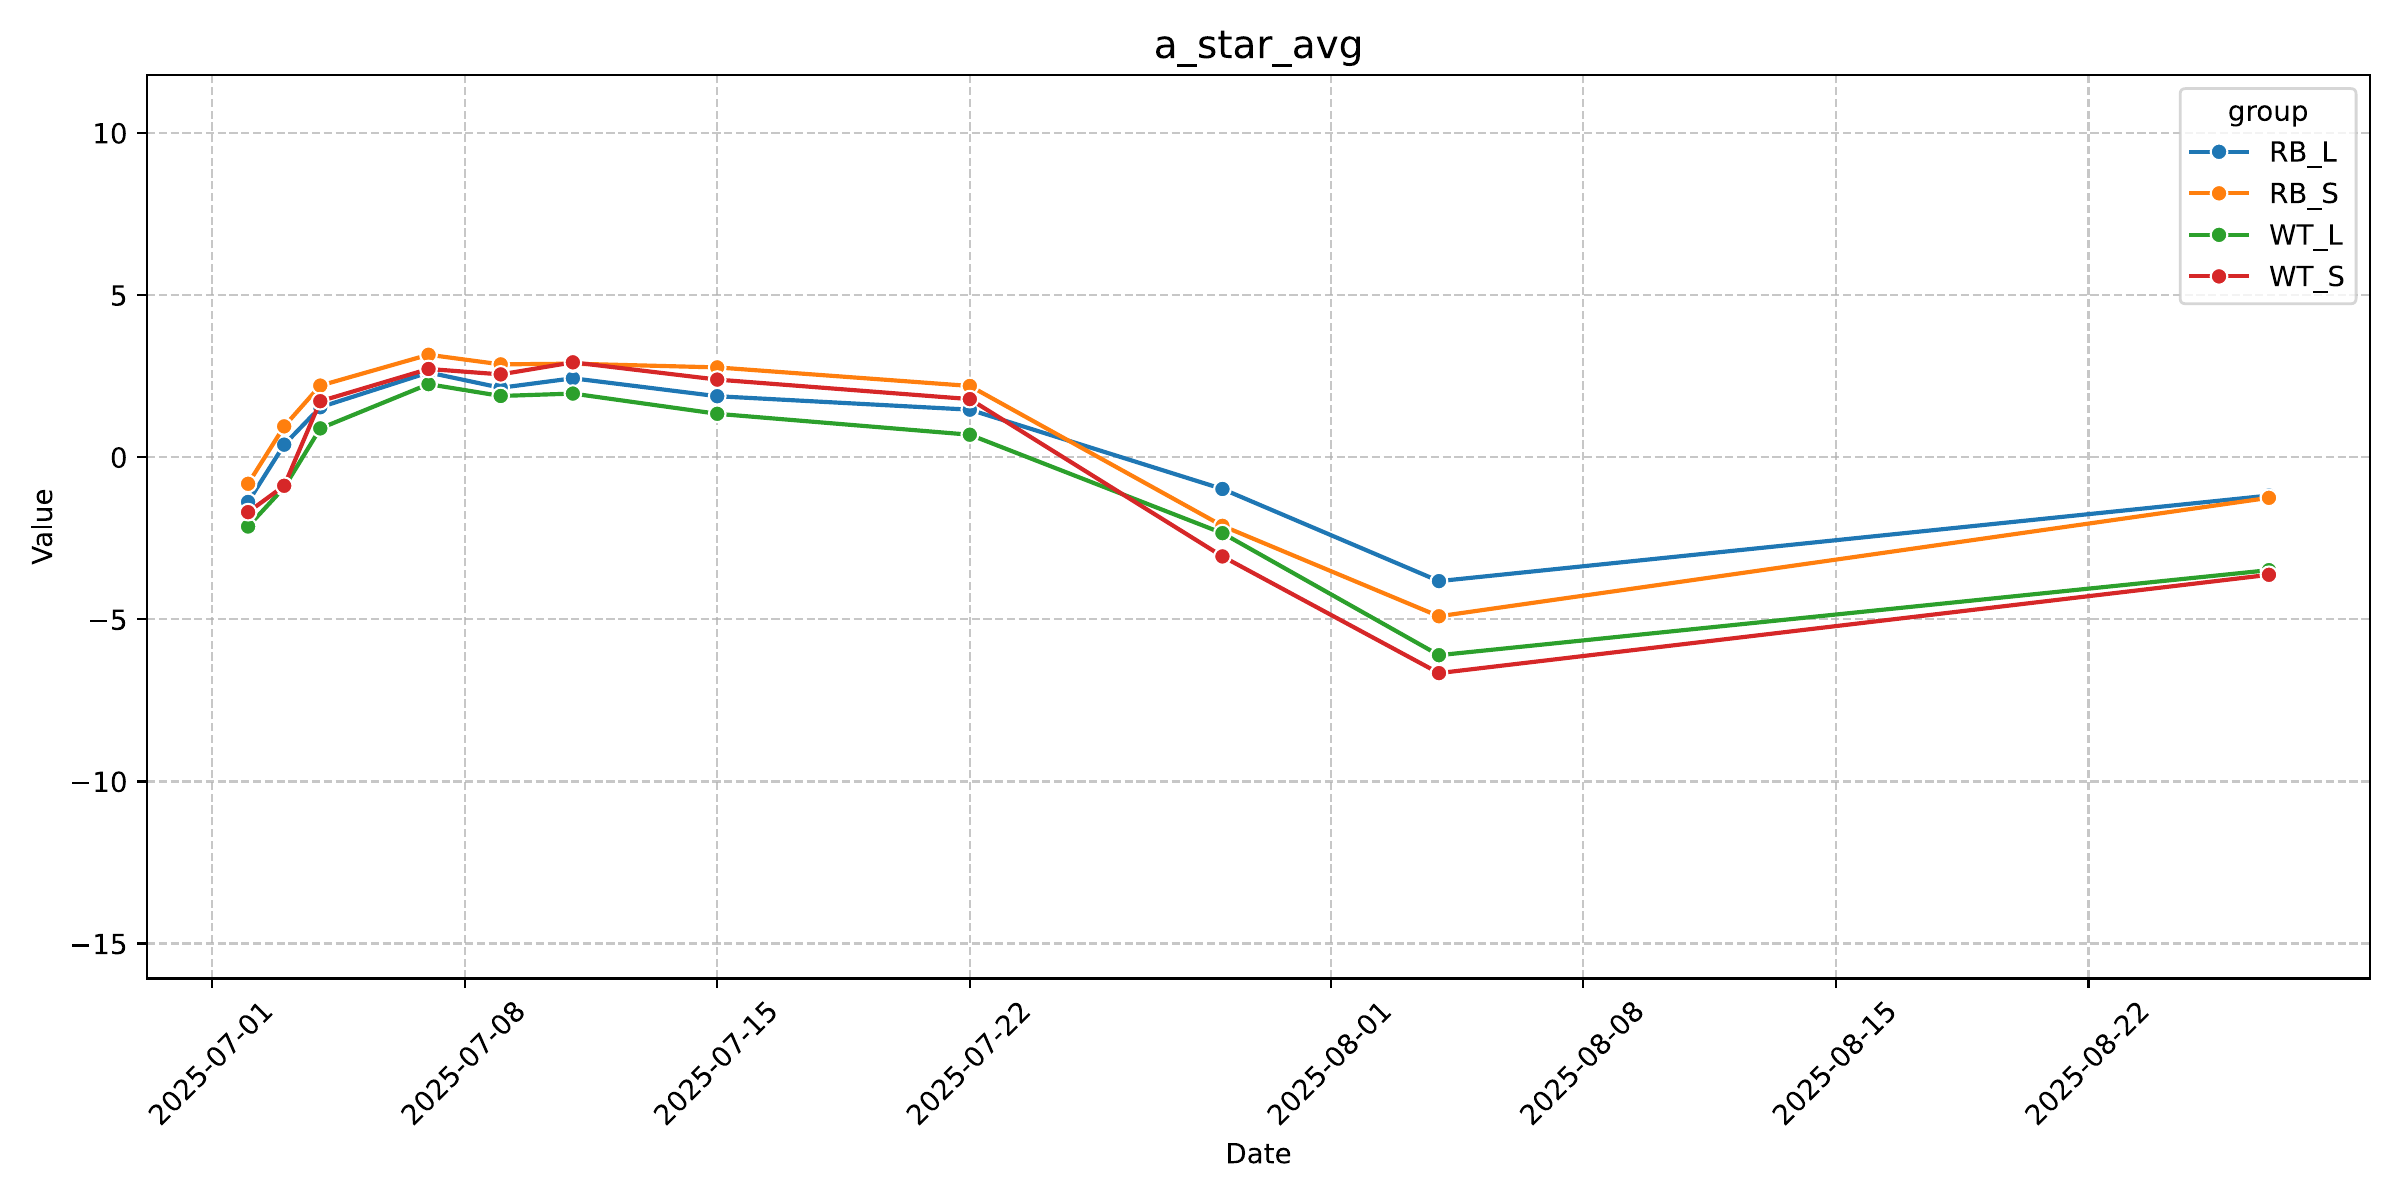

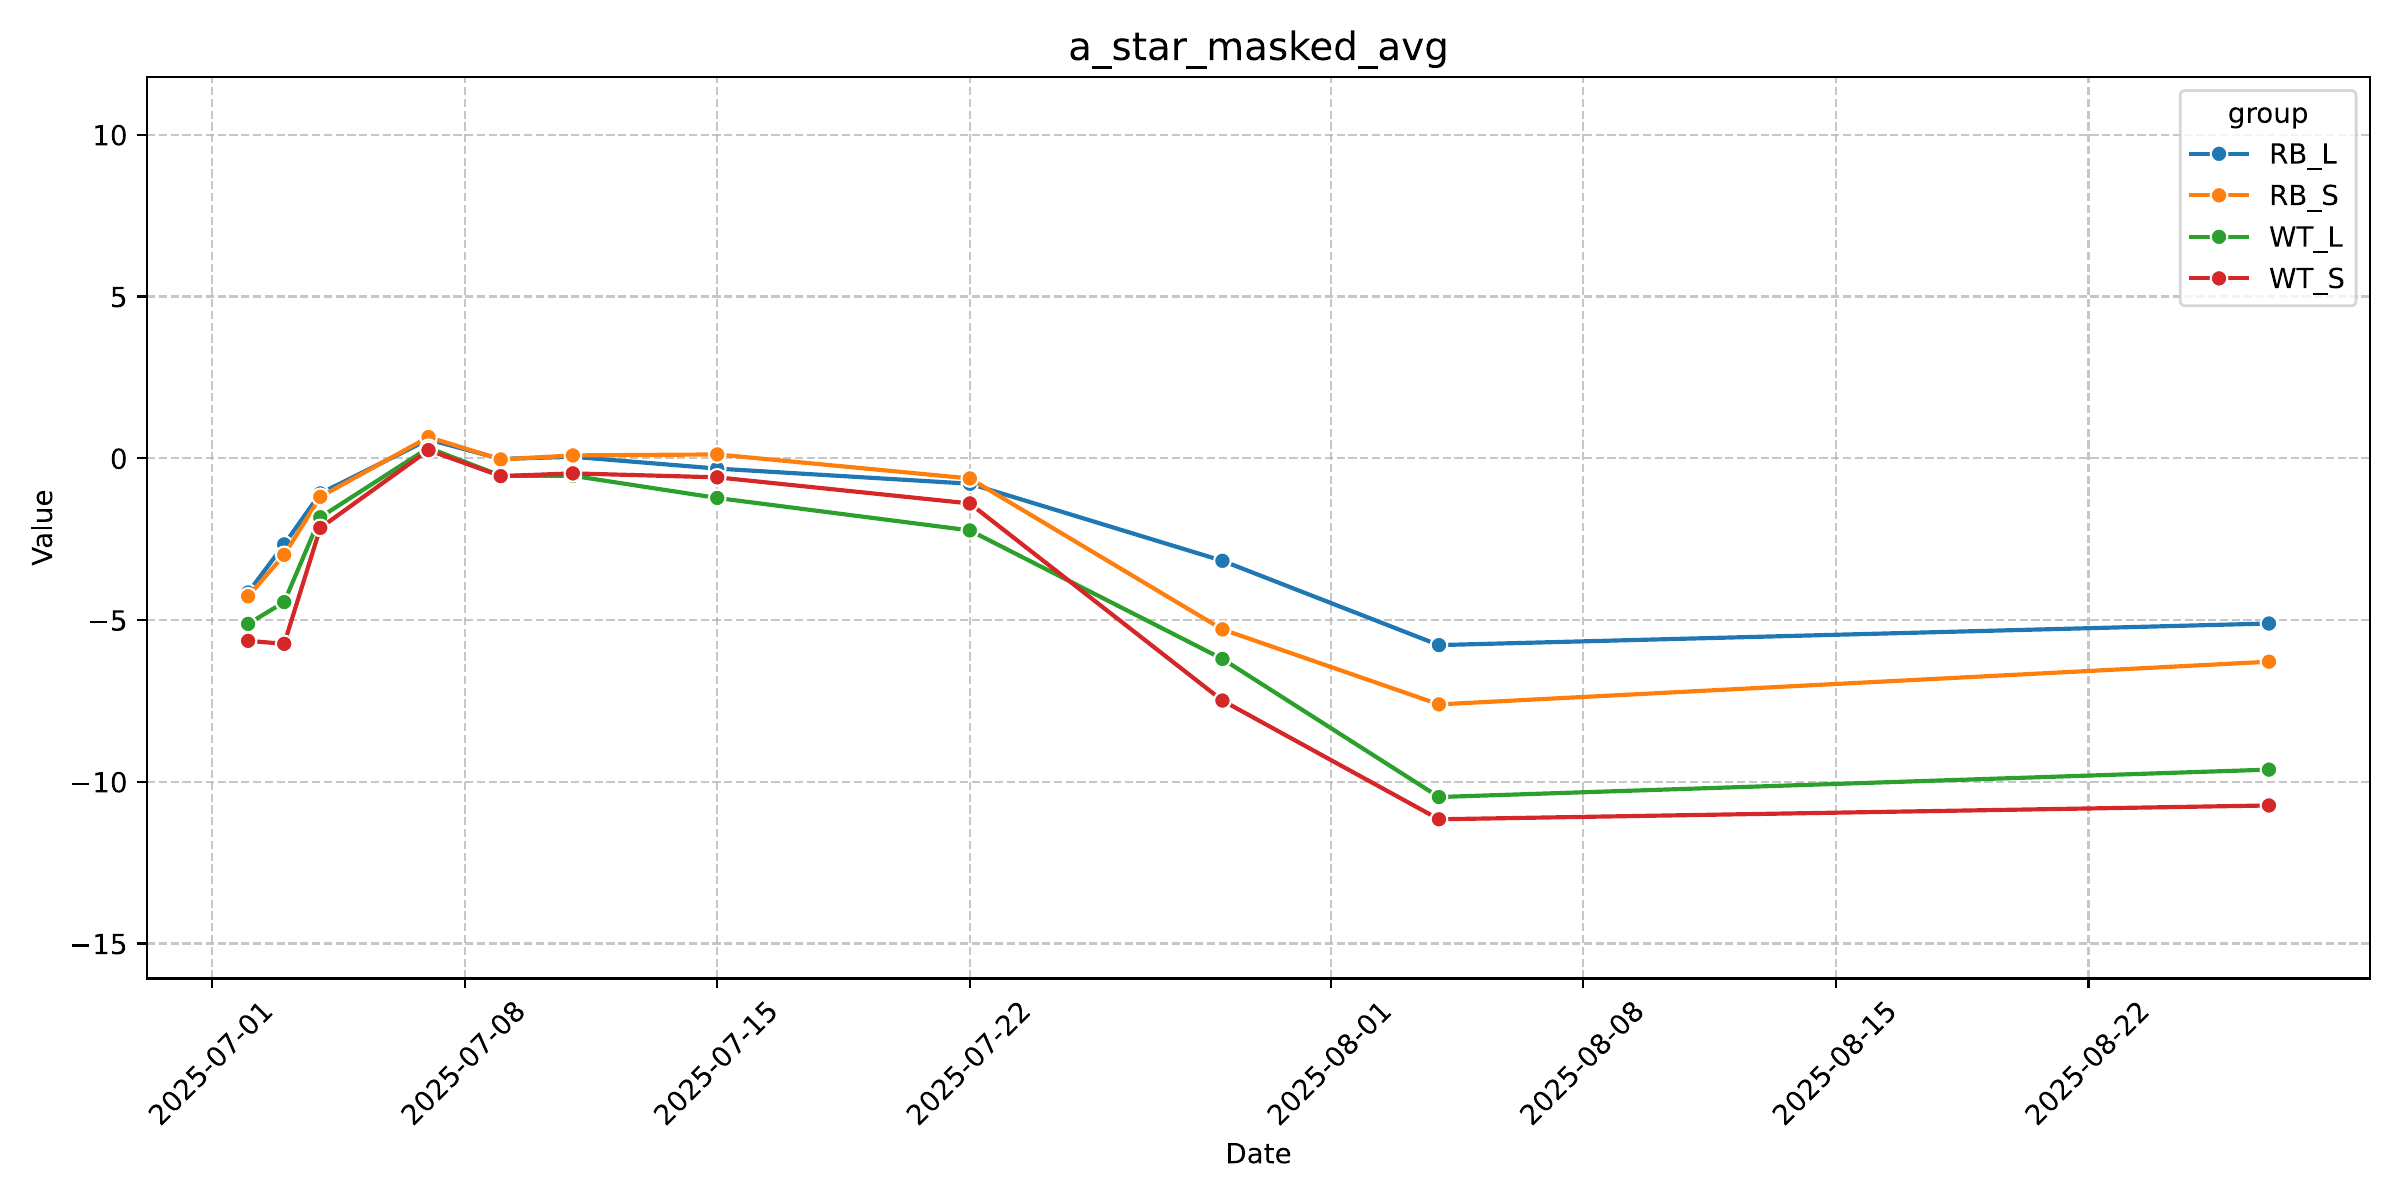

In [ ]:
pdf_path = "Multidate_Analysis/raw_a_star_across_dates.pdf"

# Convert the first page of the PDF to an image object (dpi=200 makes it crisp)
pages = convert_from_path(pdf_path, dpi=200)

# Display the image in the notebook
if pages:
    display(pages[0])
    display(pages[1])

Because the early drone data dates are uninformative without more accurate plant masks, I have chosen to do the rest of this analysis on only the last 3 drone data dates: 7/29/25, 8/04/25, and 8/27/25. 

#### Results and Discussion

The first step to analyzing $a^*$ coloration data for the last 3 drone dates is outlier removal. Plant $a^*$ values are determined by the average of all the pixels in the plant mask. The dataframe I am using contains all of the averaged a* values for all of the plants in the field for the last 3 days of drone flights. I used a model including all of the interactions between every plant genotype, nitrogen treatment, and date, as well as a random effect for plot, to account for soil variation across plots. I pulled out the residuals from this model, and standardized them based on the average value for data points of the same genotype, treatment, and date. Outliers that were further than 3 standard deviations away from this average were removed from the dataset. In the residuals vs fitted graph below, you can see the outliers above and below the red dotted lines that were removed. There were 10 outliers total that were removed. 

In [66]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import matplotlib.patches as mpatches
from scipy import stats
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np

In [67]:
import rpy2.ipython
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [87]:
%%R
# Load necessary libraries
library(tidyverse)
library(lme4)
library(lmerTest)
library(dplyr)
library(ggplot2)
library(nlme)
library(emmeans)
library(stringr)

#### Outlier Removal

In [ ]:
%%R
# Read in individual plant values for the a* index

plant_data <- read.csv("Multidate_Analysis/plant_df_PLSCI7170_final.csv", header=TRUE, stringsAsFactors=FALSE)
# Select a* index
index = "a_star_masked_avg_"
# Select necessary columns
plant_data <- plant_data %>%
  select(plantId, plotId, genotype, treatment, group, rep, starts_with(index))
# Reshape data from Wide to Long
plant_data_long <- plant_data %>%
  pivot_longer(
    cols = starts_with(index), 
    names_to = "source_col", 
    values_to = "a_star_masked_avg"
  ) %>%
  # Extract date from index column name
  mutate(date = as.factor(str_extract(source_col, "\\d{8}$"))) %>%
  # Change necessary columns to factors
  mutate(
    treatment = as.factor(treatment),
    rep = as.factor(rep),
    plotId = as.factor(plotId),
    plantId = as.factor(plantId)
  )

head(plant_data_long)

# A tibble: 6 × 9
  plantId     plotId genotype treatment group rep   source_col a_star_masked_avg
  <fct>       <fct>  <chr>    <fct>     <chr> <fct> <chr>                  <dbl>
1 25TML01.T0… 25TML… RB       L         RB_L  1     a_star_ma…             -1.79
2 25TML01.T0… 25TML… RB       L         RB_L  1     a_star_ma…             -6.90
3 25TML01.T0… 25TML… RB       L         RB_L  1     a_star_ma…             -4.53
4 25TML01.T0… 25TML… RB       L         RB_L  1     a_star_ma…             -2.36
5 25TML01.T0… 25TML… RB       L         RB_L  1     a_star_ma…             -6.16
6 25TML01.T0… 25TML… RB       L         RB_L  1     a_star_ma…             -4.29
# ℹ 1 more variable: date <fct>


In [70]:
%%R
# Model of individual plant values
model <- lmer(a_star_masked_avg ~ group * date + (1|plotId), 
                   data = plant_data_long)


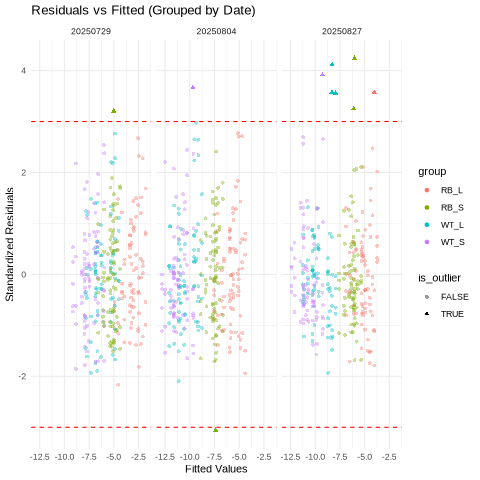

In [71]:
%%R
# Get raw residuals from the model
residual_data <- plant_data_long %>%
  mutate(
    raw_resid = resid(model),
    fitted = fitted(model)
  ) %>%
  # Group by group x date combo and standardize the residuals within each resulting pool
  group_by(group, date) %>%
  mutate(
    std_resid = raw_resid / sd(raw_resid, na.rm = TRUE),
    is_outlier = abs(std_resid) >= 3
  ) %>%
  ungroup()

# See outliers by group x date combo
ggplot(residual_data, aes(x = fitted, y = std_resid, color = group)) +
  geom_point(aes(shape = is_outlier, alpha = is_outlier)) +
  # Add 3 sd threshold lines
  geom_hline(yintercept = c(-3, 3), linetype = "dashed", color = "red") +
  # Split by date 
  facet_wrap(~date) +
  scale_alpha_manual(values = c(0.4, 1)) +
  scale_shape_manual(values = c(16, 17)) + # Circle for normal, Triangle for outlier
  labs(title = "Residuals vs Fitted (Grouped by Date)",
       x = "Fitted Values",
       y = "Standardized Residuals") +
  theme_minimal()

In [72]:
%%R
# Remove outliers from dataframe
plant_data_final <- residual_data %>%
  filter(is_outlier == FALSE) %>%
  # Remove the columns used for plotting
  select(-raw_resid, -fitted, -std_resid, -is_outlier)

# See number of outliers removed
original_n <- nrow(plant_data_long)
cleaned_n <- nrow(plant_data_final)
removed_n <- original_n - cleaned_n

print(paste("Original plant observations:", original_n))
print(paste("Observations after 3 standard deviation removal:", cleaned_n))
print(paste("Total outliers removed:", removed_n, "(", round(removed_n/original_n*100, 2), "%)"))

[1] "Original plant observations: 960"
[1] "Observations after 3 standard deviation removal: 950"
[1] "Total outliers removed: 10 ( 1.04 %)"


#### Averaging Plant Data

Next, the data was averaged. There are 5 plant values in each plot, 4 for the plots where an outlier was removed. These values were averaged so that there is one a* value per. plot. 

In [73]:
%%R
# Group data to average plant values in each plot
plot_data <- plant_data_final %>%
  group_by(plotId, date, genotype, treatment, group, rep) %>%
  summarise(
    # Calculate the mean of a*, ignoring any NAs
    a_star_plot_avg = mean(a_star_masked_avg, na.rm = TRUE),
    # Count how many plants are left in the plot after outlier removal
    plant_count = n(),
    .groups = "drop" # Clean up the grouping state
  )

# View averaged df
glimpse(plot_data)

Rows: 192
Columns: 8
$ plotId          <fct> 25TML01.T01, 25TML01.T01, 25TML01.T01, 25TML01.T02, 25…
$ date            <fct> 20250729, 20250804, 20250827, 20250729, 20250804, 2025…
$ genotype        <chr> "RB", "RB", "RB", "WT", "WT", "WT", "RB", "RB", "RB", …
$ treatment       <fct> L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, L, …
$ group           <chr> "RB_L", "RB_L", "RB_L", "WT_L", "WT_L", "WT_L", "RB_L"…
$ rep             <fct> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ a_star_plot_avg <dbl> -1.775026, -5.341743, -3.345755, -7.074462, -12.301773…
$ plant_count     <int> 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, …


#### Testing Homoscedasticity of Residuals

Individual models were made for each genotype and date combination, 6 total models. Since the genotype and date are variables accounted for in the dataset rather than the model, the only variable that needs to be accounted for in the models is treatment, and heterogenous residual variance between genotypes or dates does not need to be accounted for. I thought that there might be heterogenous residual variance between the two treatments. The plants might express a wider range of coloration when they experience more nitrogen stress, or a smaller range, if the RUBY plants stop expressing more RUBY pigment after a certain amount of stress. To test for heterogenous residual variance between treatment, I made two models with the RUBY plants for each date: one model where a covariance matrix is used, and one where no covariance matrix is used. For all of the covariance matrix models, the BIC score is higher than their counterpart non-covariance model, meaning that the covariance matrix does not account for enough variance to be worth keeping in the model. Visual inspection of the residuals shows that residual variance is higher for the standard trial than the low trial when looking at the homogenous residual variance model, however the difference in residual variance is not significant as evidenced by the non-significant p-value when comparint the two models. Because of this, I used the model without the covariance matrix for my final analysis. 

In [74]:
%%R
# Filter data for RB genotype and 20250729
RB_729 <- plot_data %>%
  filter(genotype == "RB", date == "20250729")

# Model A: assumes homogeneous residual variance 
model_RB_729 <- gls(a_star_plot_avg ~ treatment, 
                  data = RB_729, 
                  method = "REML")

# Model B: Assumes heterogeneous residual variance between the standard and low treatment
model_RB_729_hetero <- gls(a_star_plot_avg ~ treatment, 
                    data = RB_729, 
                    weights = varIdent(form = ~ 1 | treatment),
                    method = "REML")

# Compare models
anova_comparison <-anova(model_RB_729, model_RB_729_hetero)
print(anova_comparison)

                    Model df     AIC      BIC    logLik   Test  L.Ratio p-value
model_RB_729            1  3 107.430 111.6336 -50.71501                        
model_RB_729_hetero     2  4 107.865 113.4698 -49.93252 1 vs 2 1.564966  0.2109


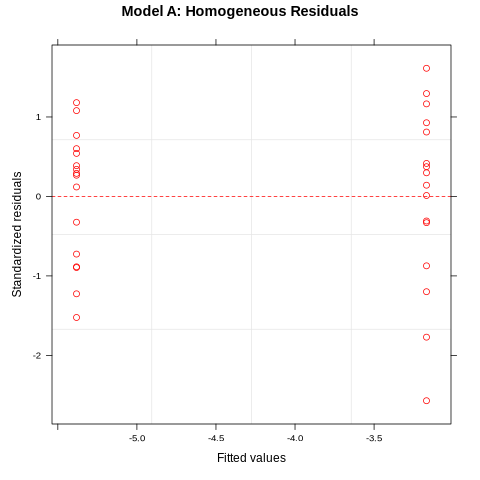

In [75]:
%%R
# Plot Model A 
plot(model_RB_729, main = "Model A: Homogeneous Residuals", 
     abline = c(0, 0), lty = 2, col = "red")

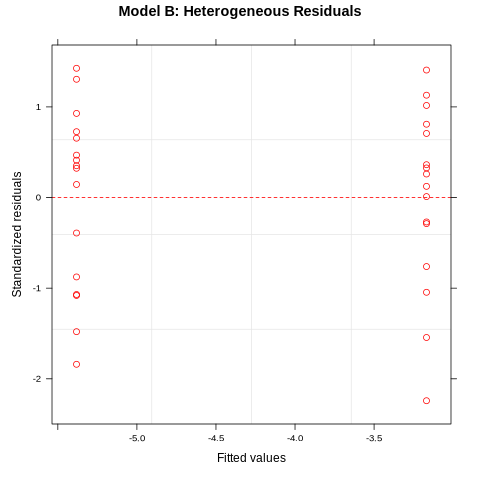

In [76]:
%%R
# Plot Model B 
plot(model_RB_729_hetero, main = "Model B: Heterogeneous Residuals", 
     abline = c(0, 0), lty = 2, col = "red")

For model A, the assumption of normality is not violated, though both tails being above the line indicates that the distribution is positively skewed:

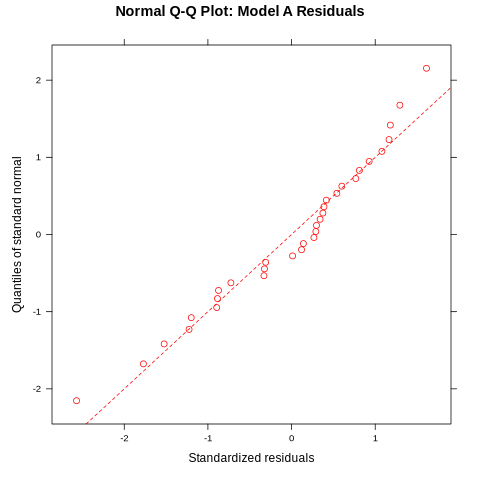

In [77]:
%%R
options(repr.plot.width = 7, repr.plot.height = 7, repr.plot.res = 150)

# Q-Q plot for standardized residuals of Model A
qqnorm(model_RB_729, abline = c(0, 1), lty = 2, col = "red",
       main = "Normal Q-Q Plot: Model A Residuals")

Below is a BIC comparison on the two other dates to see if they have similar results to the first date. They do. For both dates, the BIC of model B is higher than for model A, and there is not a significant difference between the models. 

In [78]:
%%R
# Filter data for RB genotype and 20250804
RB_804 <- plot_data %>%
  filter(genotype == "RB", date == "20250804")

# Model A: assumes homogeneous residual variance 
model_RB_804 <- gls(a_star_plot_avg ~ treatment, 
                  data = RB_804, 
                  method = "REML")

# Model B: Assumes heterogeneous residual variance between the standard and low treatment
model_B <- gls(a_star_plot_avg ~ treatment, 
                    data = RB_804, 
                    weights = varIdent(form = ~ 1 | treatment),
                    method = "REML")

# Compare models
anova_comparison <-anova(model_RB_804, model_B)
print(anova_comparison)

             Model df      AIC      BIC    logLik   Test  L.Ratio p-value
model_RB_804     1  3 102.7381 106.9417 -48.36906                        
model_B          2  4 102.1167 107.7215 -47.05837 1 vs 2 2.621363  0.1054


In [79]:
%%R
# Filter data for RB genotype and 20250827
RB_827 <- plot_data %>%
  filter(genotype == "RB", date == "20250827")

# Model A: assumes homogeneous residual variance 
model_RB_827 <- gls(a_star_plot_avg ~ treatment, 
                  data = RB_827, 
                  method = "REML")

# Model B: Assumes heterogeneous residual variance between the standard and low treatment
model_B <- gls(a_star_plot_avg ~ treatment, 
                    data = RB_827, 
                    weights = varIdent(form = ~ 1 | treatment),
                    method = "REML")

# Compare models
anova_comparison <-anova(model_RB_827, model_B)
print(anova_comparison)

             Model df      AIC      BIC    logLik   Test L.Ratio p-value
model_RB_827     1  3 98.40219 102.6058 -46.20109                       
model_B          2  4 98.12126 103.7261 -45.06063 1 vs 2 2.28093   0.131


#### Compare Difference in Groups Across Dates

The final step in this analysis is determining the difference in a* value between genotype and treatment groups for each date, using the 6 models, then comparing the differences in the model-predicted values, to see how the magnitude of difference changes across the 3 dates. 

In [80]:
%%R
# Filter data for WT and make WT models, since RB models already exist.
WT_729 <- plot_data %>%
  filter(genotype == "WT", date == "20250729")

model_WT_729 <- gls(a_star_plot_avg ~ treatment, 
                  data = WT_729, 
                  method = "REML")

WT_804 <- plot_data %>%
  filter(genotype == "WT", date == "20250804")

model_WT_804 <- gls(a_star_plot_avg ~ treatment, 
                  data = WT_804, 
                  method = "REML")

WT_827 <- plot_data %>%
  filter(genotype == "WT", date == "20250827")

model_WT_827 <- gls(a_star_plot_avg ~ treatment, 
                  data = WT_827, 
                  method = "REML")

Looking at the predicted effect values of each treatment, the differences between the low and standard nitrogen treatment are significant across all 3 dates and both genotypes. The p-values can be seen below, as well as a visual representation of the model-estimated a* value by treatment, across date. 

To conclude, the difference in a* value across dates cannot be compared without more confidence in masking, however, the magnitude of the difference between genotype and treatment can be compared. The difference between the RUBY plants in the two treatments, as well as the difference between the wildtype plants in the two treatments, decreases over the the course of the 3 drone flight dates. This may be due to changes in soil nitrogen. Soil nitrogen samples at the end of the field season showed higher nitrate and ammonia values than soil samples taken at the start of the season. Though the reason for the increase in nitrogen is unknown, decreasing differences between the coloration in the low and standard trials supports the idea the plants in the low nitrogen treatment began to recover from stress and thus show decreased red coloration.

The final trend plot can be seen below.

In [81]:
%%R

# Helper function to extract the (Standard - Low) difference 
get_treatment_diff <- function(model_obj, geno, dt) {
  contrast(emmeans(model_obj, ~ treatment), method = "pairwise") %>%
    as.data.frame() %>%
    mutate(genotype = geno, date = dt)
}

# Pull differences the 6 models
diff_trends <- bind_rows(
  get_treatment_diff(model_RB_729, "RB", "20250729"),
  get_treatment_diff(model_RB_804, "RB", "20250804"),
  get_treatment_diff(model_RB_827, "RB", "20250827"),
  get_treatment_diff(model_WT_729, "WT", "20250729"),
  get_treatment_diff(model_WT_804, "WT", "20250804"),
  get_treatment_diff(model_WT_827, "WT", "20250827")
)

# Print the clean summary table
print(diff_trends %>% select(genotype, date, contrast, estimate, SE, p.value))

  genotype     date contrast  estimate        SE      p.value
1       RB 20250729    L - S 2.2132710 0.4229172 1.205252e-05
2       RB 20250804    L - S 1.7739575 0.3911058 8.611622e-05
3       RB 20250827    L - S 1.2732696 0.3638395 1.478626e-03
4       WT 20250729    L - S 1.2855953 0.5384942 2.347092e-02
5       WT 20250804    L - S 0.8402488 0.6024662 1.733539e-01
6       WT 20250827    L - S 0.8703620 0.3929697 3.450977e-02


In [82]:
%%R

# Helper function to extract the group means 
get_treatment_means <- function(model_obj, geno, dt) {
  emmeans(model_obj, ~ treatment) %>%
    as.data.frame() %>%
    mutate(genotype = geno, date = dt)
}

# Compile predictions from all 6 models
mean_trends <- bind_rows(
  get_treatment_means(model_RB_729, "RB", "20250729"),
  get_treatment_means(model_RB_804, "RB", "20250804"),
  get_treatment_means(model_RB_827, "RB", "20250827"),
  get_treatment_means(model_WT_729, "WT", "20250729"),
  get_treatment_means(model_WT_804, "WT", "20250804"),
  get_treatment_means(model_WT_827, "WT", "20250827")
)

# "Group" column for plotting
mean_trends <- mean_trends %>%
  mutate(Group = paste(genotype, treatment, sep = " - "))

print(head(mean_trends))

  treatment    emmean        SE df

  lower.CL  upper.CL genotype     date  Group
1         L -3.168609 0.2990477 30 -3.779346 -2.557873       RB 20250729 RB - L
2         S -5.381880 0.2990477 30 -5.992617 -4.771144       RB 20250729 RB - S
3         L -5.773814 0.2765536 30 -6.338612 -5.209016       RB 20250804 RB - L
4         S -7.547772 0.2765536 30 -8.112569 -6.982974       RB 20250804 RB - S
5         L -5.202800 0.2572734 30 -5.728222 -4.677377       RB 20250827 RB - L
6         S -6.476069 0.2572734 30 -7.001491 -5.950647       RB 20250827 RB - S


In [ ]:
%%R
# Color assignments
unique_groups <- unique(mean_trends$Group)
color_assignments <- sapply(unique_groups, function(g) {
  if (grepl("RB", g)) {
    if (grepl("Low|L|low", g)) return("#FBB4AE") else return("#E41A1C")
  } else {
    if (grepl("Low|L|low", g)) return("#B3CDE3") else return("#377EB8")
  }
})

# Plot object
p_final <- ggplot(mean_trends, aes(x = as.factor(date), y = emmean, color = Group, group = Group)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 3.5) +
  geom_errorbar(aes(ymin = lower.CL, ymax = upper.CL), 
                width = 0.15, linewidth = 0.9) +
  
  # Labels
  labs(title = "Predicted a* Value by Genotype and Treatment for Last 3 Drone Dates",
       subtitle = "Y axis displays Model-Estimated Marginal Means (±95% Confidence Intervals)",
       x = "Flight Date",
       y = "Estimated a* Value",
       color = "Genotype & Treatment") +
  
  theme_minimal(base_size = 14) +
  scale_color_manual(values = color_assignments) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    legend.position = "right"
  )

# Save pdf
ggsave(
  filename = "a_star_trend_plot_final.pdf", 
  plot = p_final,
  width = 12, 
  height = 6
)

print("pdf saved")

[1] "pdf saved"


In [ ]:
pdf_path = "a_star_trend_plot_final.pdf"
IFrame(pdf_path, width=900, height=450)